# P1 v0.1 — 미국 baseline 검증 (전체 과정)

`ff_core.py`(엔진)와 `ff_data_us.py`(로더)를 불러와 **데이터 읽기 → 회귀 → GRS → 판정**을 한 단계씩 실행한다.

> 이 노트북은 **`src/` 폴더에서 열어 실행**한다 (같은 폴더의 `.py` 모듈을 import하고, `../data/`의 파일을 읽는다).

검증 기준은 "내 숫자가 알려진 결과와 맞는가". GRS 기각 여부 자체는 판정 기준이 아니다.

In [ ]:
import sys; sys.path.insert(0, '.')     # ff_core.py · ff_data_us.py 와 같은 폴더(src)
from ff_core import summarize
from ff_data_us import find_files, load_ff_us
import statsmodels.api as sm
print('불러옴: summarize (ff_core) / load_ff_us·find_files (ff_data_us)')

불러옴: summarize (ff_core) / load_ff_us·find_files (ff_data_us)


## 1단계 — 데이터 읽기

세 잣대(Mkt−RF, SMB, HML, RF)와 25개 바구니를 읽어 날짜를 맞추고 초과수익까지 만든다.
(읽고 쪼개는 일은 `ff_data_us.py`가 처리 — 여기선 결과만 본다.)

In [2]:
FACTORS, PORTS = find_files()
print('데이터:', FACTORS, '|', PORTS)
excess, factors, rf = load_ff_us(FACTORS, PORTS)
print('읽은 기간:', excess.index.min(), '~', excess.index.max(), '/', len(excess), '개월')
factors.head()

데이터: ../data/F-F_Research_Data_Factors_CSV.zip | ../data/25_Portfolios_5x5_CSV.zip
읽은 기간: 1926-07 ~ 2026-04 / 1198 개월


,Mkt-RF,SMB,HML
date,,,
1926-07,0.0289,-0.0255,-0.0239
1926-08,0.0264,-0.0114,0.0381
1926-09,0.0038,-0.0136,0.0005
1926-10,-0.0327,-0.0014,0.0082
1926-11,0.0254,-0.0011,-0.0061


## 2단계 — 공통 표본

25개가 모두 값을 가진 달만 남긴다 (GRS 공분산 계산에 필요).

In [3]:
mask = excess.notna().all(axis=1) & factors.notna().all(axis=1)
ex, fa = excess[mask], factors[mask]
print('회귀 표본:', ex.index.min(), '~', ex.index.max(), '/', len(ex), '개월,', ex.shape[1], '개 포트폴리오')
ex.iloc[:, :5].head()

회귀 표본: 1926-07 ~ 2026-04 / 1198 개월, 25 개 포트폴리오


,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,SMALL HiBM
date,,,,,
1926-07,0.056076,-0.019206,0.002918,-0.023677,0.017383
1926-08,-0.022706,-0.082782,0.011468,0.018983,0.082604
1926-09,-0.050591,-0.029106,-0.045717,-0.034983,0.006286
1926-10,-0.096833,-0.038719,-0.038224,0.031213,-0.028652
1926-11,0.052788,0.038777,0.021284,-0.047595,0.002010


## 3단계 — 25개 회귀 (한 번에)

`summarize`가 25개 회귀 + GRS를 한 번에 돌려 표로 준다. α는 월 단위 %, t는 Newey-West(HAC).

In [4]:
table, grs_res, reg = summarize(ex, fa)
disp = table.copy()
disp['alpha(%/월)'] = disp['alpha'] * 100
disp[['portfolio', 'alpha(%/월)', 'alpha_t', 'r2']].round(3)

,portfolio,alpha(%/월),alpha_t,r2
0,SMALL LoBM,-0.674,-4.710,0.663
1,ME1 BM2,-0.392,-3.580,0.823
2,ME1 BM3,-0.122,-1.979,0.889
3,ME1 BM4,0.071,1.283,0.929
4,SMALL HiBM,0.139,2.420,0.929
5,ME2 BM1,-0.210,-3.344,0.909
6,ME2 BM2,0.024,0.424,0.934
7,ME2 BM3,0.025,0.486,0.934
8,ME2 BM4,0.025,0.573,0.951
9,ME2 BM5,0.033,0.683,0.952


## 3b단계 — 한 회귀 자세히 뜯어보기

위 표의 한 줄(SMALL LoBM)이 어떻게 나온 건지, 그 회귀 하나만 자세히 본다.

In [5]:
X = sm.add_constant(fa.values)
one = sm.OLS(ex['SMALL LoBM'].values, X).fit(cov_type='HAC',
                                             cov_kwds={'maxlags': reg['hac_lags']})
print(one.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     311.8
Date:                Sun, 28 Jun 2026   Prob (F-statistic):          1.90e-149
Time:                        14:33:50   Log-Likelihood:                 1504.5
No. Observations:                1198   AIC:                            -3001.
Df Residuals:                    1194   BIC:                            -2981.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0067      0.001     -4.710      0.0

## 4단계 — GRS 결합검정

In [6]:
print(f"GRS  F = {grs_res['F']:.3f}   p = {grs_res['p_value']:.2e}   F({grs_res['dof1']}, {grs_res['dof2']})")
print('판정:', '기각 (알파가 남아 있음)' if grs_res['p_value'] < 0.05 else '기각 못 함')

GRS  F = 3.275   p = 1.18e-07   F(25, 1170)
판정: 기각 (알파가 남아 있음)


## 5단계 — 검증 판정 + 결과 저장

세 잣대 평균(역사값), R²(대부분 0.9+), 소형 성장주 음의 알파(3요인의 유명한 한계)를 확인한다.
이 패턴이 맞으면 **로직 검증 통과 = 잠금**.

In [7]:
import os
print('[세 잣대 월평균 — 역사값 대조]')
for c in ['Mkt-RF', 'SMB', 'HML']:
    print(f'  {c:7s}: {fa[c].mean()*100:+.3f}% /월')
print(f'  {"RF":7s}: {rf.loc[fa.index].mean()*100:+.3f}% /월')
print(f"\n설명력 R²  : 최소 {table['r2'].min():.3f} / 중앙값 {table['r2'].median():.3f} / 최대 {table['r2'].max():.3f}")
print(f"알파 유의   : 25개 중 {(table['alpha_t'].abs() > 1.96).sum()}개  (|t| > 1.96)")
sg = table[table['portfolio'] == 'SMALL LoBM'].iloc[0]
print(f"소형 성장주 : 알파 {sg['alpha']*100:+.3f}%/월, t = {sg['alpha_t']:+.2f}  ← 3요인이 못 잡는 유명한 구석")

os.makedirs('../results', exist_ok=True)
with open('../results/baseline_us.md', 'w', encoding='utf-8') as f:
    f.write("# 미국 baseline 검증 결과\n\n")
    f.write(f"- 표본: {ex.index.min()} ~ {ex.index.max()} ({len(ex)}개월), 25개 포트폴리오\n")
    f.write(f"- R²: 중앙값 {table['r2'].median():.3f}\n")
    f.write(f"- GRS: F={grs_res['F']:.3f}, p={grs_res['p_value']:.2e}, F({grs_res['dof1']},{grs_res['dof2']})\n\n")
    f.write("| 포트폴리오 | 알파(%/월) | t | R² |\n|---|---|---|---|\n")
    for _, r in table.iterrows():
        f.write(f"| {r['portfolio']} | {r['alpha']*100:+.3f} | {r['alpha_t']:+.2f} | {r['r2']:.3f} |\n")
print('\n결과 저장: results/baseline_us.md')

[세 잣대 월평균 — 역사값 대조]
  Mkt-RF : +0.693% /월
  SMB    : +0.166% /월
  HML    : +0.353% /월
  RF     : +0.270% /월

설명력 R²  : 최소 0.663 / 중앙값 0.926 / 최대 0.956
알파 유의   : 25개 중 9개  (|t| > 1.96)
소형 성장주 : 알파 -0.674%/월, t = -4.71  ← 3요인이 못 잡는 유명한 구석

결과 저장: results/baseline_us.md


## (보너스) 25개 알파 지도

5×5 격자. 왼쪽 위(소형·성장)가 짙은 색으로 튄다 — 3요인 모형의 알려진 약점.

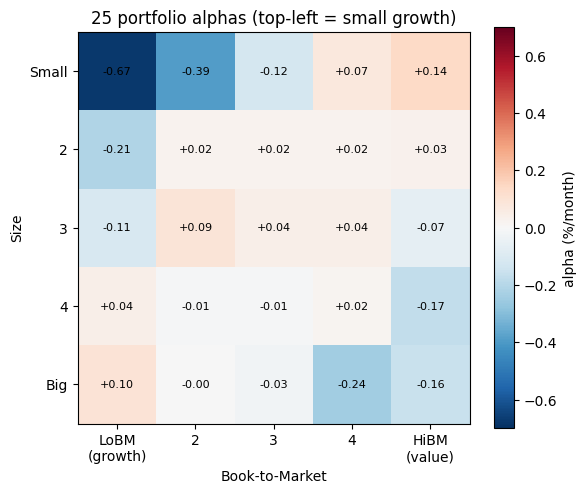

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

grid = table['alpha'].values.reshape(5, 5) * 100   # 행=크기, 열=B/M
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(grid, cmap='RdBu_r', vmin=-0.7, vmax=0.7)
ax.set_xticks(range(5)); ax.set_xticklabels(['LoBM\n(growth)', '2', '3', '4', 'HiBM\n(value)'])
ax.set_yticks(range(5)); ax.set_yticklabels(['Small', '2', '3', '4', 'Big'])
ax.set_xlabel('Book-to-Market'); ax.set_ylabel('Size')
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{grid[i, j]:+.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, label='alpha (%/month)')
ax.set_title('25 portfolio alphas (top-left = small growth)')
plt.tight_layout(); plt.show()